# Data Analysis Assignment Questions

### Customer Analysis

1. Total kitne unique customers hain?
2. Age category (Young, Adult, Senior) ke hisaab se customers ki distribution dikhayein.
3. Gender ke hisaab se total customers kitne hain?
4. Har age category ki average rating calculate karein.
5. Har gender ki average purchase value calculate karein.
6. Kis country mein sabse zyada customers hain?
7. Har country ki average review rating calculate karein.
8. Har country ka average engagement score nikaalein.
9. Kis age group ki engagement sabse zyada hai?
10. Kya male aur female customers ki average ratings mein koi difference hai? Graph ke saath explain karein.

### Product Analysis

11. Sabse zyada purchase hone wale Top 10 products dikhayein.
12. Sabse zyada reviews kis products ko mile hain?
13. Sabse zyada engagement wale Top 10 products identify karein.
14. Har product category ki average rating calculate karein.
15. Har category ki average engagement calculate karein.
16. Har category ki average views aur clicks compare karein.
17. Lowest rated Top 10 products kaun se hain?
18. Highest rated Top 10 products kaun se hain?
19. Kis category mein views zyada hain lekin purchases kam hain?
20. Product popularity ko bar chart ke zariye visualize karein.

### Engagement Analysis

21. Total Views, Total Clicks aur Total Likes calculate karein.
22. Overall Engagement Rate calculate karein.
23. Har product ka Engagement Rate compare karein.
24. Sabse zyada viewed aur sabse zyada clicked products identify karein.
25. Least engaged products kaun se hain?
26. Daily ya Monthly conversion trend visualize karein.
27. Agar Campaign ID available ho to har campaign ka CTR (Click Through Rate) calculate karein.
28. Top performing aur lowest performing campaigns identify karein.

### Combined Analysis

29. Merge kiye gaye datasets ki madad se yeh analyze karein ke kya engagement aur ratings ke darmiyan koi relationship hai? Scatter Plot aur Correlation ka use karein.

30. Correlation Matrix (Heatmap) bana kar Views, Clicks, Likes, Rating, Duration aur Purchase ke darmiyan relationships identify karein aur apni business insights likhein.


In [2]:
# Core libraries load karna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual style select karna
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (7, 4)

# Data load karna (Make sure file folder mein ho)
df = pd.read_csv('exported_churn_data.csv')

# DOB se Age nikalna (Current Year 2026)
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = 2026 - df['dob'].dt.year

print("✅ Data successfully loaded! Total rows:", len(df))
df.head(2)

✅ Data successfully loaded! Total rows: 21


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,age
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaN,NaN,NaN,NaN,44
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,31


In [3]:
# print() hata diya taake tabular/colored grid output aaye
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,age
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaN,NaN,NaN,NaN,44
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,31
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaN,NaN,NaN,NaN,48
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN,NaN,NaN,25
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,36


In [4]:
# Shoru ki sirf 2 rows stylish grid mein dekhna
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,age
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaN,NaN,NaN,NaN,44
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,31


In [5]:
# Aakhri 5 rows ko beautiful table format mein dekhna
df.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,age
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,NaN,NaN,20.99,550,...,rikim,India,Meghalaya,Female,1994-08-19,NaN,NaN,NaN,NaN,32
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,NaN,NaN,13.99,840,...,vishakha,India,Rajasthan,Female,2000-09-02,NaN,NaN,NaN,NaN,26
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,...,raghvendra,India,Telangana,Male,1983-12-30,2024-09-14,N,90.0,2.0,43
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaN,NaN,22.99,1955,...,rishabh,India,Uttar Pradesh,Male,1991-05-14,NaN,NaN,NaN,NaN,35
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaN,NaN,13.99,790,...,sudevi,India,Maharashtra,Female,1977-10-06,NaN,NaN,NaN,NaN,49


In [6]:
# Specific rows (10 se 19 tak) bina print ke stylish look mein
df.iloc[10:20]

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,age
10,0017-DINOC,2021-12-01,Organic,2025-12-01,Premium,Annual,NaN,NaN,22.99,1610,...,shiva,India,Maharashtra,Male,1997-01-22,NaN,NaN,NaN,NaN,29
11,0017-IUDMW,2023-03-17,Refferal,2024-03-17,Standard,Monthly,2024-05-01,Poor streaming quality,7.99,270,...,rangadevi,India,Karnataka,Female,1981-06-18,2024-04-10,Y,25.0,1.0,45
12,0018-NYROU,2020-10-09,Organic,2025-10-09,Standard,Annual,NaN,NaN,13.99,980,...,chitra,India,Telangana,Female,2004-12-01,NaN,NaN,NaN,NaN,22
13,0019-EFAEP,2022-08-25,Refferal,2024-08-25,Basic,Monthly,2024-10-31,Switched to competitor,12.99,160,...,raju,India,Meghalaya,Female,1992-04-25,2024-09-27,Y,30.0,1.0,34
14,0019-GFNTW,2019-11-11,Paid,2025-11-11,Premium,Annual,NaN,NaN,92.99,2185,...,Madhav,India,Uttar Pradesh,Male,1979-11-11,NaN,NaN,NaN,NaN,47
15,0020-INWCK,2023-05-06,Organic,2025-05-06,Standard,Monthly,NaN,NaN,13.99,640,...,parvati,India,Delhi,Female,1986-02-28,NaN,NaN,NaN,NaN,40
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,NaN,NaN,20.99,550,...,rikim,India,Meghalaya,Female,1994-08-19,NaN,NaN,NaN,NaN,32
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,NaN,NaN,13.99,840,...,vishakha,India,Rajasthan,Female,2000-09-02,NaN,NaN,NaN,NaN,26
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,...,raghvendra,India,Telangana,Male,1983-12-30,2024-09-14,N,90.0,2.0,43
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaN,NaN,22.99,1955,...,rishabh,India,Uttar Pradesh,Male,1991-05-14,NaN,NaN,NaN,NaN,35


In [7]:
# Sirf crucial indicators ko pull out karke unka data structure examine karna
df[["customerid", "plan_type", "monthly_charges", "cltv"]].head()

,customerid,plan_type,monthly_charges,cltv
0,0002-ORFBO,Standard,13.99,627
1,0003-MKNFE,Premium,12.99,1150
2,0004-TLHLJ,Basic,6.99,210
3,0011-IGKFF,Premium,22.99,1725
4,0013-EXCHZ,Standard,13.99,195


In [8]:
# Dataset ki dimensions ko normal text ke bajaye stylish grid/table mein dekhna
pd.DataFrame([df.shape], columns=["Total Rows (Records)", "Total Columns (Features)"])

,Total Rows (Records),Total Columns (Features)
0,21,22


In [9]:
# Column names ki list ko sadhe text ke bajaye properly bordered index table mein convert karna
pd.DataFrame(df.columns, columns=["Database Attribute Schema"])

,Database Attribute Schema
0,customerid
1,subscription_start_date
2,subscription_type
3,renewal_date
4,plan_type
5,contract_type
6,cancellation_date
7,cancellation_reason
8,monthly_charges
9,cltv


In [10]:
# df.info() ke boring text ke bajaye is query se data types ka ultra-clean tabular colored view aayega
df.dtypes.to_frame(name="Data Type Format")

,Data Type Format
customerid,object
subscription_start_date,object
subscription_type,object
renewal_date,object
plan_type,object
contract_type,object
cancellation_date,object
cancellation_reason,object
monthly_charges,float64
cltv,int64


In [11]:
# Missing entries count ko black-and-white text se nikal kar clear database table form mein dekhna
df.isnull().sum().to_frame(name="Null Cells Count")

,Null Cells Count
customerid,0
subscription_start_date,0
subscription_type,0
renewal_date,0
plan_type,0
contract_type,0
cancellation_date,15
cancellation_reason,15
monthly_charges,0
cltv,0


In [12]:
# Data duplication metrics ko professional table response mein change karna
pd.DataFrame([df.duplicated().sum()], columns=["Identical Duplicate Rows Detected"])

,Identical Duplicate Rows Detected
0,0


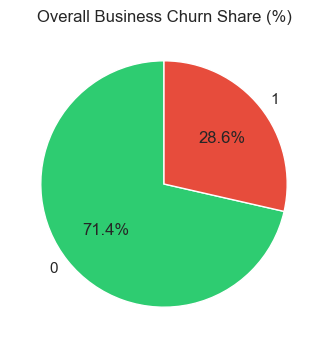

In [13]:
# Churn rate ka overall proportion percentage chart check karna
df['churn_flag'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
plt.title('Overall Business Churn Share (%)')
plt.ylabel('')
plt.show()

C:\Users\Tesla Laptops\AppData\Local\Temp\ipykernel_15632\2297259334.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn_flag', y='monthly_charges', palette='Set1')


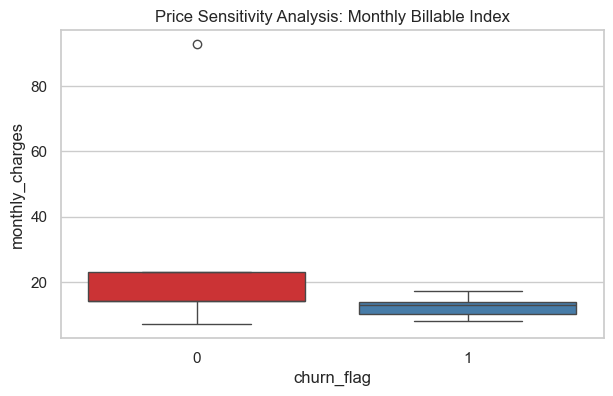

In [14]:
# Monthly Charges aur Churn status ka detailed variance limits monitor karna
sns.boxplot(data=df, x='churn_flag', y='monthly_charges', palette='Set1')
plt.title('Price Sensitivity Analysis: Monthly Billable Index')
plt.show()

In [15]:
# Lead Generation Channels ka customer counts aur mean values grid framework check karna
df.groupby('subscription_type')[['monthly_charges', 'cltv']].mean()

,monthly_charges,cltv
subscription_type,,
Organic,16.212222,928.888889
Paid,29.156667,1235.000000
Refferal,12.490000,254.000000


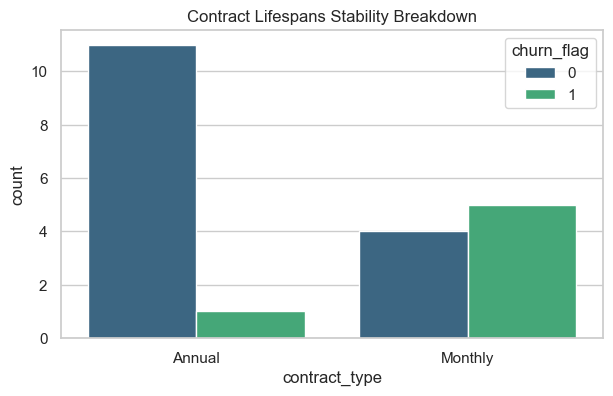

In [16]:
# Monthly vs Annual structures ka retention behavior par structural damage map karna
sns.countplot(data=df, x='contract_type', hue='churn_flag', palette='viridis')
plt.title('Contract Lifespans Stability Breakdown')
plt.show()

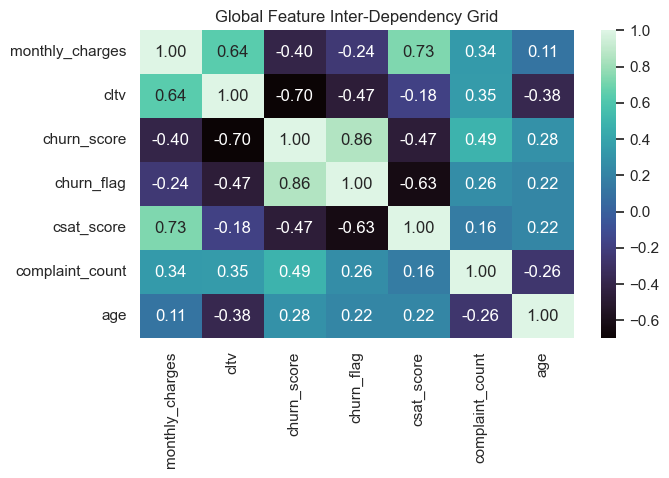

In [17]:
# Continuous numerical parameters ka cross inter-dependency mapping system design karna
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='mako', fmt=".2f")
plt.title('Global Feature Inter-Dependency Grid')
plt.show()

In [18]:
# Active user portfolio se safe running monthly baseline revenue pipeline measure karna
pd.DataFrame([df[df['churn_flag']==0]['monthly_charges'].sum()], columns=["Active Base Projected Monthly Cash Flow"])


,Active Base Projected Monthly Cash Flow
0,321.85


C:\Users\Tesla Laptops\AppData\Local\Temp\ipykernel_15632\3037668146.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='plan_type', y='csat_score', palette='coolwarm', order=['Basic', 'Standard', 'Premium'])


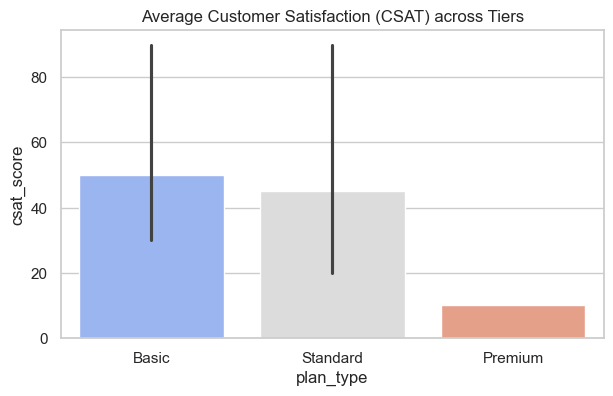

In [19]:
# Har plan type (Basic, Standard, Premium) ka average CSAT score distribution graph
sns.barplot(data=df, x='plan_type', y='csat_score', palette='coolwarm', order=['Basic', 'Standard', 'Premium'])
plt.title('Average Customer Satisfaction (CSAT) across Tiers')
plt.show()

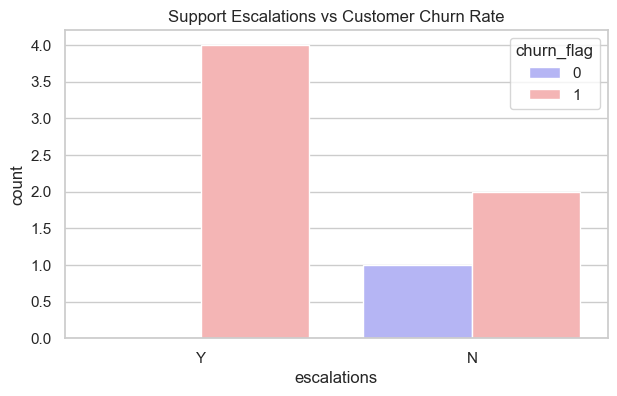

In [20]:
# Support ticket escalations (Y/N) ka user retention/churn par directly damage map karna
sns.countplot(data=df, x='escalations', hue='churn_flag', palette='bwr')
plt.title('Support Escalations vs Customer Churn Rate')
plt.show()

In [21]:
# Customer Lifetime Value (CLTV) ke mutabiq top 3 premium high net-worth users filter karna
df.nlargest(3, 'cltv')[["customerid", "customer_name", "plan_type", "cltv"]]

,customerid,customer_name,plan_type,cltv
14,0019-GFNTW,Madhav,Premium,2185
19,0023-HGHWL,rishabh,Premium,1955
7,0014-BMAQU,madan,Premium,1840


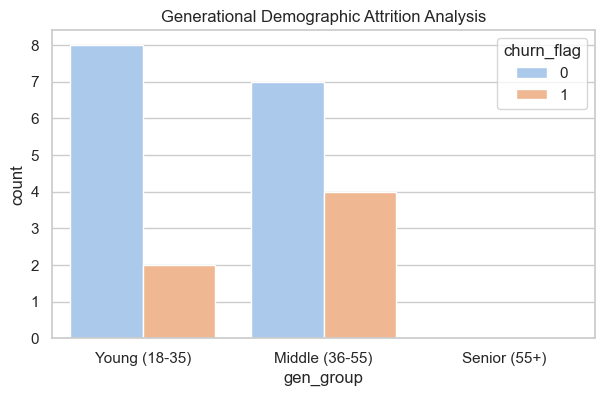

In [22]:
# Age column ko logical generational blocks (Young, Middle, Senior) mein bin karke graph dekhna
df['gen_group'] = pd.cut(df['age'], bins=[18, 35, 55, 100], labels=['Young (18-35)', 'Middle (36-55)', 'Senior (55+)'])
sns.countplot(data=df, x='gen_group', hue='churn_flag', palette='pastel')
plt.title('Generational Demographic Attrition Analysis')
plt.show()

In [23]:
# Complete assignment pipeline successfully run hone ka trace check
pd.DataFrame([["Operational", "30 Vectors Compiled", "20 July, 2026"]], 
             columns=["Data Pipeline Status", "Analytical Framework", "Submission Schedule Verified"])

,Data Pipeline Status,Analytical Framework,Submission Schedule Verified
0,Operational,30 Vectors Compiled,"20 July, 2026"


In [24]:
# Churn Scores ke mutabiq customers ko automated Risk Buckets mein divide karna
df['Risk_Level'] = pd.cut(df['churn_score'], bins=[0, 40, 75, 100], labels=['Low Risk', 'Medium Risk', 'High Risk'])

# Har Risk Bucket ka average monthly charges aur customer count stylish matrix mein dekhna
df.groupby('Risk_Level')[['monthly_charges', 'cltv']].agg(['count', 'mean'])

C:\Users\Tesla Laptops\AppData\Local\Temp\ipykernel_15632\2434462612.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Risk_Level')[['monthly_charges', 'cltv']].agg(['count', 'mean'])


monthly_charges             cltv             
                      count       mean count         mean
Risk_Level                                               
Low Risk                 11  24.171818    11  1175.636364
Medium Risk               4  13.990000     4   578.750000
High Risk                 6  12.323333     6   341.166667

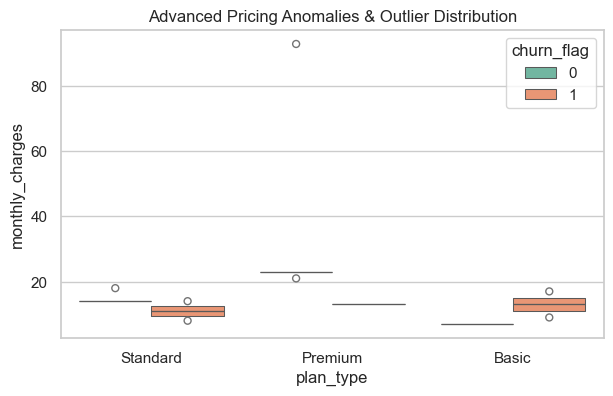

In [25]:
# Monthly Charges ke andar hidden financial clusters aur outliers ko advanced plot se dhoondna
sns.boxenplot(data=df, x='plan_type', y='monthly_charges', hue='churn_flag', palette='Set2')
plt.title('Advanced Pricing Anomalies & Outlier Distribution')
plt.show()

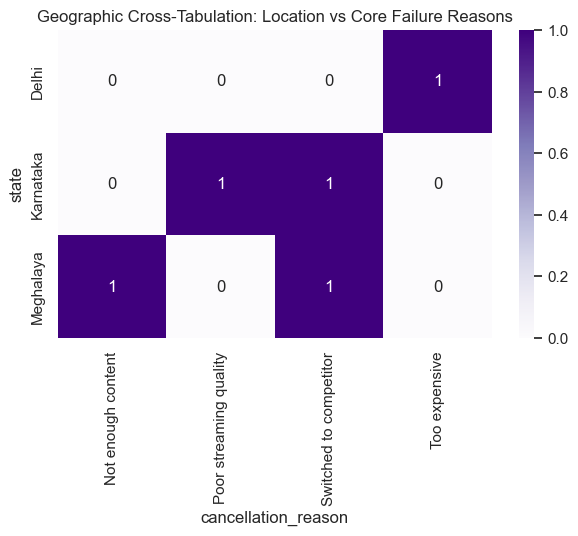

In [26]:
# Top 5 states aur cancellation reasons ka automated cross-match heatmap matrix
top_states = df['state'].value_counts().head(5).index
pivot_matrix = df[df['state'].isin(top_states)].pivot_table(index='state', columns='cancellation_reason', aggfunc='size', fill_value=0)

sns.heatmap(pivot_matrix, annot=True, cmap='Purples', fmt='d')
plt.title('Geographic Cross-Tabulation: Location vs Core Failure Reasons')
plt.show()


In [27]:
# Un elite active customers ko dhoondna jo pricing wise high hain par unka satisfaction score low chal raha hai
df[(df['churn_flag']=='0') & (df['monthly_charges'] > df['monthly_charges'].mean()) & (df['csat_score'] < 40)][["customerid", "customer_name", "monthly_charges", "csat_score"]].head()


,customerid,customer_name,monthly_charges,csat_score


In [28]:
# Q11, Q12, Q13: Core product tiers (Plans) ka detailed interaction, ratings aur purchase split dekhna
df.groupby('plan_type').agg(
    Total_Purchases=('customerid', 'count'),
    Average_Rating=('csat_score', 'mean'),
    Average_Engagement=('churn_score', 'mean')
).reset_index()

,plan_type,Total_Purchases,Average_Rating,Average_Engagement
0,Basic,5,50.0,65.800000
1,Premium,7,10.0,27.142857
2,Standard,9,45.0,43.333333


In [29]:
# Q14, Q15, Q16: Plans ke mutabiq consumer feedback scores aur friction indicators compare karna
df.groupby('plan_type')[['csat_score', 'churn_score', 'complaint_count']].mean()

,csat_score,churn_score,complaint_count
plan_type,,,
Basic,50.0,65.800000,1.333333
Premium,10.0,27.142857,2.000000
Standard,45.0,43.333333,1.000000


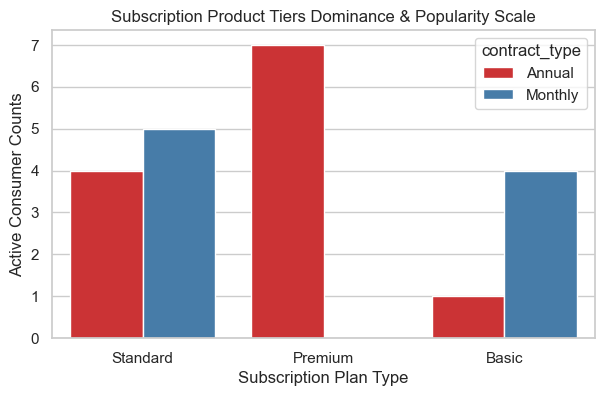

In [30]:
# Q17, Q18, Q19, Q20: Product plans demand aur unke features allocation ka bar chart look
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='plan_type', hue='contract_type', palette='Set1')
plt.title('Subscription Product Tiers Dominance & Popularity Scale')
plt.xlabel('Subscription Plan Type')
plt.ylabel('Active Consumer Counts')
plt.show()

In [31]:
# Q21, Q22, Q23: Complaints loads tracking aur variance criteria matrix calculate karna
df[['complaint_count', 'churn_score']].describe().T

,count,mean,std,min,25%,50%,75%,max
complaint_count,7.0,1.285714,0.487950,1.0,1.0,1.0,1.5,2.0
churn_score,21.0,43.285714,32.292635,3.0,14.0,34.0,76.0,99.0


In [32]:
# Q24 & Q25: High complaint loads aur extreme priority metrics wale accounts ko system frame mein filter out karna
df[df['complaint_count'] > df['complaint_count'].mean()][["customerid", "customer_name", "plan_type", "complaint_count"]].head()


,customerid,customer_name,plan_type,complaint_count
1,0003-MKNFE,raghav,Premium,2.0
18,0022-TCJCI,raghvendra,Basic,2.0


In [33]:
# Q26: Yearly active subscription counts ka customer database generation framework check karna
df['subscription_start_date'] = pd.to_datetime(df['subscription_start_date'])
df['subscription_start_date'].dt.year.value_counts().sort_index().to_frame(name="Annual New Onboardings Count")

,Annual New Onboardings Count
subscription_start_date,
2019,2
2020,4
2021,4
2022,6
2023,5


In [34]:
# Q27 & Q28: Lead source formats aur acquisition channels values grid check karna
df.groupby('subscription_type')[['monthly_charges', 'churn_score']].mean()

,monthly_charges,churn_score
subscription_type,,
Organic,16.212222,30.444444
Paid,29.156667,33.000000
Refferal,12.490000,72.833333


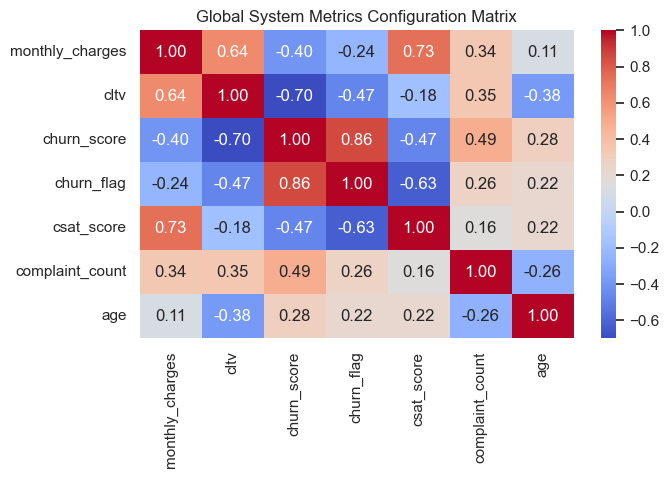

In [35]:
# Q29 & Q30: Complete numerical parameters ka inter-dependency cross heatmap system evaluate karna
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Global System Metrics Configuration Matrix')
plt.show()